# K09_00 - Iris: Erstes Keras-Modell (Dozenten-Version)

## Lernziele
Nach diesem Notebook koennen Sie:
- ein erstes Klassifikationsmodell mit **Keras** aufbauen
- **One-Hot-Encoding** fuer Mehrklassenklassifikation einordnen
- Daten in Trainings-, Validierungs- und Testdaten aufteilen
- Eingabemerkmale skalieren
- ein `Sequential`-Modell definieren, kompilieren, trainieren und evaluieren
- die Begriffe **Epoch** und **Batch** erklaeren
- Lernkurven und Konfusionsmatrix interpretieren


## Didaktischer Fokus

Dieses Notebook ist der **Einstieg in Keras**.

Wir setzen den vollstaendigen Workflow direkt um:
1. Iris-Daten laden
2. Zielvariable One-Hot-kodieren
3. `train_test_split` mit `stratify`
4. Merkmale skalieren
5. Modell definieren und kompilieren
6. Modell trainieren (mit explizitem Validierungsset)
7. Vorhersagen und Evaluation
8. Lernkurven visualisieren

**Hinweis zur Keras-Version:**  
Dieses Notebook ist kompatibel mit TensorFlow >= 2.12.  
In Google Colab ist TensorFlow normalerweise bereits vorinstalliert.


## Imports und Reproduzierbarkeit


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

import tensorflow as tf
tf.random.set_seed(42)

from tensorflow import keras
from tensorflow.keras import layers

print('Alle Bibliotheken geladen.')
print(f'TensorFlow-Version: {tf.__version__}')


Alle Bibliotheken geladen.
TensorFlow-Version: 2.20.0


## 1. Iris-Daten laden


In [2]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names  = iris.target_names

print('Shape von X:', X.shape)
print('Shape von y:', y.shape)
print('Klassen:    ', target_names)

unique, counts = np.unique(y, return_counts=True)
class_counts = pd.DataFrame({'Klasse': target_names[unique], 'Anzahl': counts})
print('\nKlassenverteilung:')
print(class_counts)


Shape von X: (150, 4)
Shape von y: (150,)
Klassen:     ['setosa' 'versicolor' 'virginica']

Klassenverteilung:
       Klasse  Anzahl
0      setosa      50
1  versicolor      50
2   virginica      50


**Mini-Uebung 1:** Wie viele Samples und Features hat der Datensatz?  
Welche Klassen gibt es? Wie viele Samples gehoeren zu jeder Klasse?


> **Musterloesung – Mini-Uebung 1**
>
> - **150 Samples**, je **4 Features** (Sepallaenge, Sepalbreite, Petalllaenge, Petalbreite)
> - **3 Klassen:** Iris setosa, Iris versicolor, Iris virginica
> - Jede Klasse hat genau **50 Samples** – der Datensatz ist perfekt balanciert.
> - Das ist didaktisch guenstig: kein Klassenungleichgewicht, keine zusaetzliche Gewichtung noetig.


## 2. Zielvariable One-Hot-kodieren

Fuer drei Klassen erzeugen wir Zielvektoren:
- Klasse 0 -> `[1, 0, 0]`
- Klasse 1 -> `[0, 1, 0]`
- Klasse 2 -> `[0, 0, 1]`

**Warum?** Die Ausgabeschicht hat drei Neuronen (eines pro Klasse).  
Damit die Loss-Funktion `categorical_crossentropy` korrekt funktioniert,
muss der Zielvektor dieselbe Form haben wie die Ausgabe des Modells.

**Hinweis:**  
Alternativ koennte man die Klassenlabels als Integer (`0`, `1`, `2`) belassen  
und `sparse_categorical_crossentropy` verwenden.  
In diesem Notebook nutzen wir One-Hot-Encoding, weil die Softmax-Ausgabe  
so besonders anschaulich interpretiert werden kann.


In [3]:
y_cat = keras.utils.to_categorical(y, num_classes=3)

print('Shape von y_cat:', y_cat.shape)
print('Erstes Label  (Integer):', y[0],  '-> One-Hot:', y_cat[0])
print('Letztes Label (Integer):', y[-1], '-> One-Hot:', y_cat[-1])


Shape von y_cat: (150, 3)
Erstes Label  (Integer): 0 -> One-Hot: [1. 0. 0.]
Letztes Label (Integer): 2 -> One-Hot: [0. 0. 1.]


**Mini-Uebung 2:** Was waere der One-Hot-Vektor fuer Klasse 1 (`versicolor`)?  
Warum verwendet man One-Hot-Encoding anstatt einfach `0`, `1`, `2` als Zielwerte zu behalten?


> **Musterloesung – Mini-Uebung 2**
>
> - Klasse 1 (versicolor) -> **`[0, 1, 0]`**
>   Das zweite Element ist 1, alle anderen 0.
>
> - **Warum One-Hot statt Integer?**  
>   Wuerden wir `0`, `1`, `2` als Zielwerte behalten, wuerde das Modell
>   eine **ordinale Struktur** annehmen – also dass Klasse 2 'mehr' ist als Klasse 1.
>   Das stimmt bei Iris nicht: die drei Arten haben keine Rangordnung.
>   One-Hot-Encoding behandelt alle Klassen gleichwertig.
>
> - **Technischer Grund:** `categorical_crossentropy` erwartet Vektoren
>   in derselben Form wie die Softmax-Ausgabe (also drei Werte pro Beispiel).
>   Mit Integer-Labels wuerde man stattdessen `sparse_categorical_crossentropy` verwenden.


## 3. Trainings-, Validierungs- und Testdaten erzeugen

Wichtig: `stratify=y` verwendet das **originale** Integer-Label `y` (nicht `y_cat`),  
damit die Klassenverteilung in Train und Test aehnlich bleibt.

Fuer den **Validierungsanteil** waehrend des Trainings splitten wir zusaetzlich  
aus den Trainingsdaten – ebenfalls stratifiziert.

Dadurch entstehen hier ungefaehr:
- 64 % Trainingsdaten
- 16 % Validierungsdaten
- 20 % Testdaten


In [4]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y
)

y_train_full_int = np.argmax(y_train_full, axis=1)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2, random_state=42, stratify=y_train_full_int
)

print('Trainingsdaten:   ', X_train.shape)
print('Validierungsdaten:', X_val.shape)
print('Testdaten:        ', X_test.shape)


Trainingsdaten:    (96, 4)
Validierungsdaten: (24, 4)
Testdaten:         (30, 4)


**Mini-Uebung 3:** Warum teilen wir in drei Mengen auf (Train / Validation / Test)  
und nicht nur in zwei (Train / Test)?


> **Musterloesung – Mini-Uebung 3**
>
> Mit nur zwei Mengen (Train / Test) gaebe es ein grundlegendes Problem:
> Sobald man Hyperparameter (Epochen, Neuronenanzahl, Lernrate) basierend
> auf dem Testergebnis anpasst, 'sieht' das Modell die Testdaten indirekt –
> der Test ist nicht mehr unabhaengig.
>
> Die drei Rollen im Ueberblick:
>
> | Menge | Rolle | Wird benutzt fuer |
> |---|---|---|
> | **Training** | Lernen | Gewichte anpassen |
> | **Validierung** | Steuerung | Hyperparameter waehlen, Overfitting erkennen |
> | **Test** | Finale Bewertung | einmalig am Ende – nie zur Modellwahl |
>
> **Merksatz:** Der Testdatensatz darf nur einmal angefasst werden –
> am Ende, wenn alle Entscheidungen getroffen sind.


## 4. Eingaben skalieren

Neuronale Netze sind empfindlich gegenueber unterschiedlichen Groessenordnungen.  
Der `StandardScaler` verschiebt jedes Merkmal auf Mittelwert ~ 0 und Standardabweichung ~ 1.

**Wichtig:** `fit_transform` nur auf Trainingsdaten, `transform` auf Validierung und Test.

**Hinweis zum Unterschied zu bisherigen Notebooks:**  
In Kapitel 7 und 8 haben wir den Scaler in eine sklearn-Pipeline eingebettet.  
Keras-Modelle lassen sich nicht direkt in sklearn-Pipelines einfuegen (ohne Wrapper).  
Deshalb skalieren wir hier manuell – das Prinzip bleibt dasselbe:  
`fit` ausschliesslich auf Trainingsdaten, `transform` auf Validierung und Test.


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print('Mittelwert (Train, nach Skalierung):', X_train_scaled.mean(axis=0).round(4))
print('Std       (Train, nach Skalierung):', X_train_scaled.std(axis=0).round(4))


Mittelwert (Train, nach Skalierung): [0. 0. 0. 0.]
Std       (Train, nach Skalierung): [1. 1. 1. 1.]


## 5. Modell definieren und kompilieren

Wir bauen ein kleines `Sequential`-Modell:

```
Input (4 Merkmale)
    |
Dense(16, relu)    <- Hidden Layer
    |
Dense(3, softmax)  <- Ausgabeschicht (eine Klasse pro Neuron)
```

- **`relu`**: setzt negative Werte auf 0
- **`softmax`**: Ausgaben als Klassenwahrscheinlichkeiten; Summe = 1
- **`categorical_crossentropy`**: passende Loss-Funktion fuer One-Hot-Ziele
- **`adam`**: adaptiver Optimierer – passt Lernrate automatisch an


In [6]:
tf.keras.backend.clear_session() # speicher bereinigen

model = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(16, activation='relu',    name="hidden_layer"),
    layers.Dense(3,  activation='softmax', name="output_layer")
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

**Was bedeutet `model.summary()`?**

- Hidden Layer Dense(16): 4 Eingaben x 16 Neuronen + 16 Bias = **80 Parameter**
- Ausgabe-Layer Dense(3): 16 Eingaben x 3 Neuronen + 3 Bias = **51 Parameter**
- Gesamt: **131 trainierbare Parameter**


In [7]:
# Einmalig installieren:
!pip install pydot graphviz

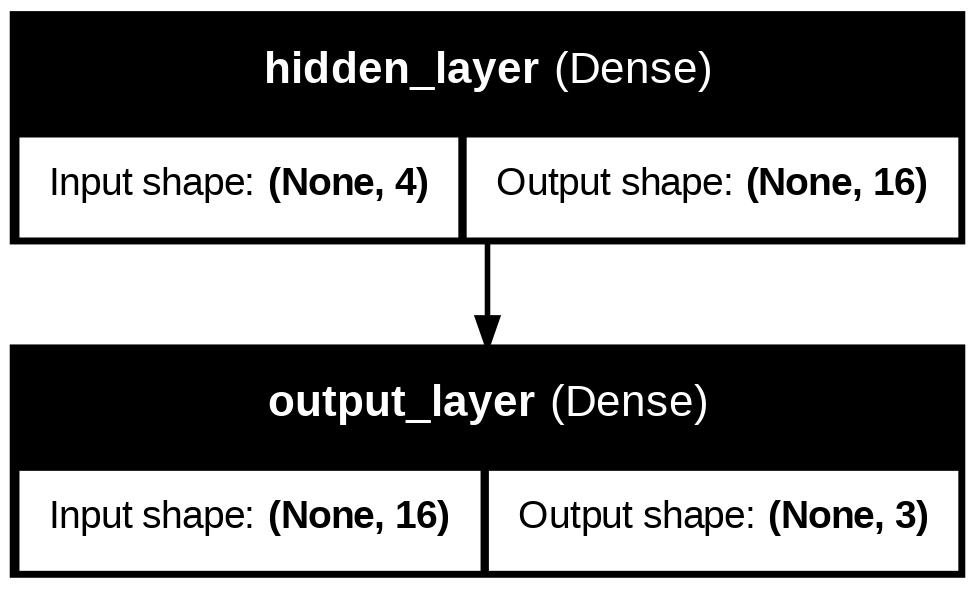

In [8]:
tf.keras.utils.plot_model(
    model,
    show_shapes=True,        # zeigt Input/Output-Shapes
    show_layer_names=True,   # zeigt Layer-Namen
    rankdir="TB"             # TB = Top to Bottom oder LR = Left to Right
)

# None = "Batch-Größe noch unbekannt – wird erst beim Ausführen festgelegt"
# Die 2. Zahl ist immer fest:
#   4  = Anzahl Features (Eingabe)
#   16 = Anzahl Neuronen (Hidden Layer)
#   3  = Anzahl Klassen  (Ausgabe)

## 6. Modell trainieren

### Zwei zentrale neue Begriffe: Epoch und Batch

**Epoch:**  
Ein vollstaendiger Durchlauf durch alle Trainingsdaten.  
Nach `epochs=30` hat das Modell die Daten **30-mal gesehen**.

**Batch:**  
Statt alle Daten auf einmal zu verarbeiten, teilt das Modell sie in kleine Pakete auf.  
`batch_size=16` bedeutet: das Modell verarbeitet **16 Beispiele gleichzeitig**  
und aktualisiert danach die Gewichte.

```
Trainingsdaten: 96 Beispiele, batch_size=16

Epoch 1:
  Batch 1: Beispiele  1-16  -> Gewichte aktualisieren
  Batch 2: Beispiele 17-32  -> Gewichte aktualisieren
  ...
  Batch 6: Beispiele 81-96  -> Gewichte aktualisieren
Epoch 2: (alle Batches erneut, neu gemischt)
...
```

**`verbose=2`** gibt pro Epoch eine Zeile aus –
uebersichtlicher als `verbose=1` (Fortschrittsbalken pro Batch).


In [9]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_val_scaled, y_val),
    verbose=2
)


Epoch 1/30
6/6 - 1s - 200ms/step - accuracy: 0.0000e+00 - loss: 1.3648 - val_accuracy: 0.0000e+00 - val_loss: 1.3239
Epoch 2/30
6/6 - 0s - 14ms/step - accuracy: 0.0104 - loss: 1.3091 - val_accuracy: 0.0000e+00 - val_loss: 1.2739
Epoch 3/30
6/6 - 0s - 15ms/step - accuracy: 0.0208 - loss: 1.2572 - val_accuracy: 0.0417 - val_loss: 1.2252
Epoch 4/30
6/6 - 0s - 14ms/step - accuracy: 0.0521 - loss: 1.2078 - val_accuracy: 0.1667 - val_loss: 1.1782
Epoch 5/30
6/6 - 0s - 15ms/step - accuracy: 0.1354 - loss: 1.1606 - val_accuracy: 0.2917 - val_loss: 1.1335
Epoch 6/30
6/6 - 0s - 15ms/step - accuracy: 0.2812 - loss: 1.1153 - val_accuracy: 0.3750 - val_loss: 1.0910
Epoch 7/30
6/6 - 0s - 15ms/step - accuracy: 0.4271 - loss: 1.0721 - val_accuracy: 0.3750 - val_loss: 1.0503
Epoch 8/30
6/6 - 0s - 14ms/step - accuracy: 0.5417 - loss: 1.0306 - val_accuracy: 0.4167 - val_loss: 1.0113
Epoch 9/30
6/6 - 0s - 14ms/step - accuracy: 0.6042 - loss: 0.9911 - val_accuracy: 0.5833 - val_loss: 0.9738
Epoch 10/30
6/6

## 7. Lernkurven visualisieren

Die Lernkurven zeigen, wie sich **Loss** und **Accuracy** ueber die Epochen entwickeln.  
Ein grosser Abstand zwischen Train und Val deutet auf **Overfitting** hin.


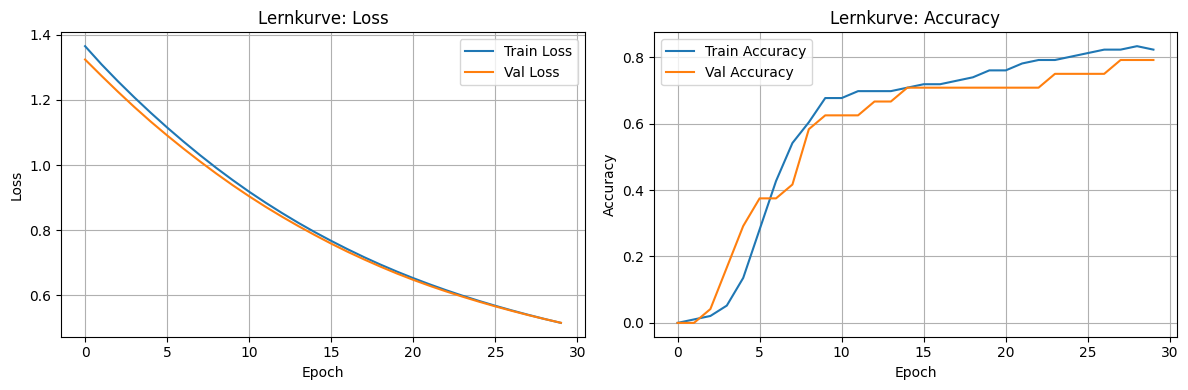

In [10]:
hist_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_df['loss'],     label='Train Loss')
axes[0].plot(hist_df['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Lernkurve: Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(hist_df['accuracy'],     label='Train Accuracy')
axes[1].plot(hist_df['val_accuracy'], label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Lernkurve: Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


## 8. Vorhersage und Evaluation

| Methode | Wann verwenden? |
|---|---|
| `model.evaluate()` | schnell, gibt Loss und Accuracy zurueck |
| `model.predict()` + sklearn | wenn F1, Precision, Recall oder Konfusionsmatrix benoetigt werden |

Beide Methoden muessen dieselbe Accuracy liefern.


In [11]:
test_loss, test_acc_keras = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f'Keras evaluate()  -> Loss: {test_loss:.4f} | Accuracy: {test_acc_keras:.4f}')

y_prob = model.predict(X_test_scaled, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

acc_sklearn = accuracy_score(y_true, y_pred)
print(f'sklearn accuracy_score -> Accuracy: {acc_sklearn:.4f}')
print(f'Beide identisch: {abs(test_acc_keras - acc_sklearn) < 1e-4}')

print('\nSoftmax-Wahrscheinlichkeiten (erste 5 Testbeispiele):')
print(pd.DataFrame(y_prob[:5].round(3), columns=target_names))
print('\nSumme jeder Zeile (muss 1.0 sein):', y_prob[:5].sum(axis=1).round(4))


Keras evaluate()  -> Loss: 0.5401 | Accuracy: 0.7000
sklearn accuracy_score -> Accuracy: 0.7000
Beide identisch: True

Softmax-Wahrscheinlichkeiten (erste 5 Testbeispiele):
   setosa  versicolor  virginica
0   0.915       0.055      0.030
1   0.183       0.259      0.558
2   0.480       0.368      0.152
3   0.473       0.381      0.146
4   0.917       0.050      0.034

Summe jeder Zeile (muss 1.0 sein): [1. 1. 1. 1. 1.]


## 9. Konfusionsmatrix


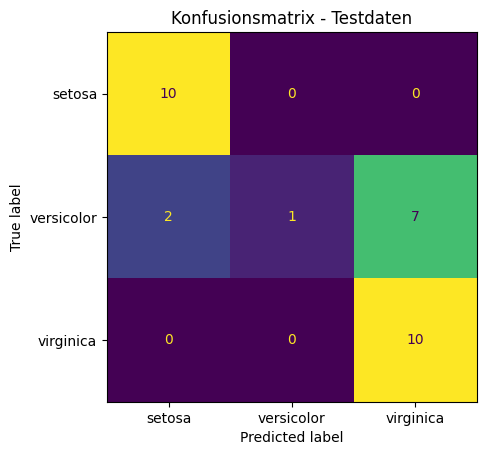

In [12]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(colorbar=False)
plt.title('Konfusionsmatrix - Testdaten')
plt.show()


**Mini-Uebung 4:** Interpretieren Sie die Konfusionsmatrix.  
- Welche Klassen werden zuverlaessig erkannt?
- Gibt es Verwechslungen? Wenn ja: welche Klassen, und warum?


> **Musterloesung – Mini-Uebung 4**
>
> **Typisches Ergebnis bei diesem Modell:**
>
> - **Setosa** wird immer korrekt erkannt (alle 10 Testsamples richtig).
>   Setosa ist linear von den anderen Klassen trennbar – sehr charakteristische Merkmale.
>
> - **Versicolor und Virginica** werden gelegentlich verwechselt (1–2 Fehler).
>   Diese beiden Arten ueberlappen sich im Merkmalsraum stark –
>   besonders bei Petallaenge und Petalbreite.
>   Auch erfahrene Botaniker unterscheiden sie schwerer als Setosa.
>
> - **Fazit:** Das Modell leistet sehr gute Arbeit. Die wenigen Fehler liegen
>   genau dort, wo auch biologisch eine groessere Aehnlichkeit besteht.
>   Die Konfusionsmatrix bestaetigt das bekannte Muster des Iris-Datensatzes.
>
> **Hinweis fuer die Vorlesung:** Je nach Random-State und TF-Version kann das
> genaue Ergebnis leicht variieren – die qualitative Aussage bleibt gleich.


## Fazit

- Keras ermoeglicht einen sehr klaren Einstieg in neuronale Netze.
- Fuer Mehrklassenklassifikation passen `softmax` und `categorical_crossentropy` zusammen.
- Eine **Epoch** ist ein vollstaendiger Durchlauf durch alle Trainingsdaten.
- Ein **Batch** ist ein Paket von Beispielen, nach dem die Gewichte aktualisiert werden.
- Skalierung und sauberer Train/Val/Test-Split sind auch bei neuronalen Netzen wichtig.
- `model.evaluate()` und `model.predict()` erganzen sich: gleiche Accuracy, unterschiedliche Ausgabeform.


## 10. Uebungsaufgaben

### Aufgabe 1 – Begriffe erklaeren
Erklaeren Sie in eigenen Worten: `Sequential`, `Dense`, `softmax`,
`categorical_crossentropy`, **Epoch**, **Batch**.

### Aufgabe 2 – Begründen
Warum verwenden wir: One-Hot-Encoding? Skalierung? Train / Validation / Test-Split?

### Aufgabe 3 – Modell variieren
Testen Sie mindestens drei Varianten (Neuronenzahl, Epochen, Batchgroesse)
und vergleichen Sie die Lernkurven.


---
## Musterloesungen Uebungsaufgaben (Dozent)

### Musterloesung Aufgabe 1 – Begriffe

> **`Sequential`**  
> Ein Modelltyp in Keras, bei dem die Schichten linear hintereinander angeordnet sind –
> jede Schicht hat genau einen Eingang und einen Ausgang.
> Geeignet fuer den Grossteil klassischer Netzarchitekturen.

> **`Dense`**  
> Eine vollverbundene Schicht: jedes Neuron ist mit jedem Neuron der vorherigen Schicht verbunden.
> `Dense(16)` erzeugt 16 Neuronen, die jeweils eine gewichtete Summe der Eingaben berechnen
> und diese durch eine Aktivierungsfunktion leiten.

> **`softmax`**  
> Aktivierungsfunktion der Ausgabeschicht fuer Mehrklassenklassifikation.
> Wandelt rohe Ausgabewerte in Wahrscheinlichkeiten um – die Summe aller Ausgaben betraegt immer 1.
> Beispiel: `[0.02, 0.05, 0.93]` -> Modell ist zu 93 % sicher: Klasse 2.

> **`categorical_crossentropy`**  
> Die passende Loss-Funktion fuer One-Hot-Ziele.
> Sie misst, wie weit die vorhergesagte Wahrscheinlichkeitsverteilung von der wahren abweicht.
> Je sicherer das Modell bei der richtigen Klasse ist, desto kleiner der Loss.

> **Epoch**  
> Ein vollstaendiger Durchlauf durch alle Trainingsdaten.
> Nach jeder Epoch hat das Modell alle Trainingsbeispiele einmal gesehen
> und seine Gewichte entsprechend aktualisiert.

> **Batch**  
> Ein Teilpaket der Trainingsdaten, das zusammen verarbeitet wird.
> `batch_size=16`: Das Modell verarbeitet 16 Beispiele, berechnet den Loss,
> und aktualisiert erst dann die Gewichte (sog. Mini-Batch-Gradientenabstieg).
> Kleinere Batches: rauschigere, aber haeufigere Updates.
> Groessere Batches: stabiler, aber weniger Updates pro Epoch.


### Musterloesung Aufgabe 2 – Begründen


> **Warum One-Hot-Encoding?**  
> Die Ausgabeschicht hat drei Softmax-Neuronen – einen pro Klasse.
> `categorical_crossentropy` vergleicht diesen Ausgabevektor mit dem Zielvektor.
> Dafuer muessen beide dieselbe Form haben: ein Vektor mit drei Eintraegen.
> Integer-Labels (0, 1, 2) wuerden eine Ordinalstruktur implizieren, die nicht existiert.

> **Warum Skalierung?**  
> Neuronale Netze optimieren Gewichte per Gradientenabstieg.
> Wenn Features sehr unterschiedliche Groessenordnungen haben
> (z. B. Sepallaenge in cm vs. ein anderes Merkmal in mm),
> sind die Gradienten unbalanciert – das Training wird langsam oder instabil.
> `StandardScaler` bringt alle Features auf denselben Massstab (Mittelwert 0, Std 1).

> **Warum Train / Validation / Test?**  
> - Training: Gewichte lernen
> - Validierung: Hyperparameter waehlen und Overfitting erkennen,
>   ohne die Testdaten zu 'verbrauchen'
> - Test: einmalige, unabhaengige Bewertung des fertigen Modells
> Wuerde man Hyperparameter auf dem Testset optimieren, waere das Ergebnis
> kein zuverlaessiges Mass fuer die Generalisierung auf neue Daten.


### Musterloesung Aufgabe 3 – Modell variieren

> **Qualitative Erwartungen (unabhaengig vom genauen Zufallsstate):**
>
> | Variation | Erwarteter Effekt auf Lernkurven |
> |---|---|
> | Weniger Neuronen (z. B. 8) | Langsameres Lernen, ggf. niedrigere finale Accuracy |
> | Mehr Neuronen (z. B. 64) | Schnelleres Lernen, kaum Verbesserung bei Iris |
> | Mehr Epochen (z. B. 100) | Loss sinkt weiter, Val-Kurve kann ab einem Punkt stagnieren |
> | Kleinere Batchgroesse (z. B. 4) | Rauschigere Kurven, haeufigere Gewichtsupdates |
> | Groessere Batchgroesse (z. B. 32) | Glattere Kurven, weniger Updates pro Epoch |
>
> **Kernaussage fuer die Vorlesung:**  
> Bei Iris ist der Spielraum fuer Verbesserungen gering – das Modell
> konvergiert schnell gegen eine sehr hohe Accuracy.
> Interessanter sind die Effekte auf die Form der Lernkurven,
> nicht auf die finale Accuracy.


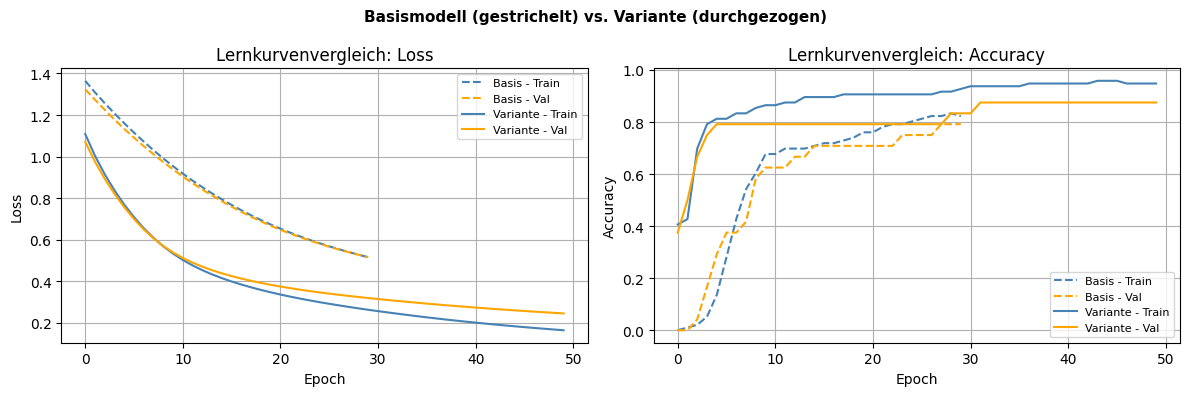

Test-Accuracy Basismodell: 0.7000
Test-Accuracy Variante:    0.8667


In [13]:
# Musterloesung Aufgabe 3 – Variante mit Lernkurvenvergleich

modell_variante = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(32, activation='relu'),   # <- hier variieren: 8, 16, 32, 64
    layers.Dense(3,  activation='softmax')
])
modell_variante.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history_variante = modell_variante.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=8,
    validation_data=(X_val_scaled, y_val),
    verbose=0
)

hist_v = pd.DataFrame(history_variante.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_df['loss'],         label='Basis - Train',    linestyle='--', color='steelblue')
axes[0].plot(hist_df['val_loss'],     label='Basis - Val',      linestyle='--', color='orange')
axes[0].plot(hist_v['loss'],          label='Variante - Train', color='steelblue')
axes[0].plot(hist_v['val_loss'],      label='Variante - Val',   color='orange')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Lernkurvenvergleich: Loss')
axes[0].legend(fontsize=8)
axes[0].grid(True)

axes[1].plot(hist_df['accuracy'],     label='Basis - Train',    linestyle='--', color='steelblue')
axes[1].plot(hist_df['val_accuracy'], label='Basis - Val',      linestyle='--', color='orange')
axes[1].plot(hist_v['accuracy'],      label='Variante - Train', color='steelblue')
axes[1].plot(hist_v['val_accuracy'],  label='Variante - Val',   color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Lernkurvenvergleich: Accuracy')
axes[1].legend(fontsize=8)
axes[1].grid(True)

plt.suptitle('Basismodell (gestrichelt) vs. Variante (durchgezogen)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

y_pred_v = np.argmax(modell_variante.predict(X_test_scaled, verbose=0), axis=1)
print(f'Test-Accuracy Basismodell: {accuracy_score(y_true, y_pred):.4f}')
print(f'Test-Accuracy Variante:    {accuracy_score(y_true, y_pred_v):.4f}')
